# Наивный Байес — SMS Spam Collection

**Метод:** Multinomial Naive Bayes — вероятностный классификатор, основанный на теореме Байеса с допущением условной независимости признаков. Для текстовой классификации это один из самых удачных и быстрых методов: документ представляется как «мешок слов», и для каждого класса оцениваются вероятности появления слов. Здесь обучаем NB на датасете SMS Spam Collection — 5572 SMS-сообщения с метками `ham` / `spam`.

## 1. Используемые библиотеки

In [1]:
import string
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, classification_report, confusion_matrix, roc_curve,
)

## 2. Загрузка и просмотр датасета

In [2]:
df = pd.read_csv("spam.csv", encoding="latin-1")

print("Размер датасета:", df.shape)
print("\nПервые 5 строк:")
print(df.head())

print("\nИнформация о датасете:")
print(df.info())

print("\nПропуски по колонкам:")
print(df.isnull().sum())

print("\nРаспределение классов (v1):")
print(df["v1"].value_counts())

Размер датасета: (5574, 2)

Первые 5 строк:
     v1                                                 v2
0   ham  Go until jurong point, crazy.. Available only ...
1   ham                      Ok lar... Joking wif u oni...
2  spam  Free entry in 2 a wkly comp to win FA Cup fina...
3   ham  U dun say so early hor... U c already then say...
4   ham  Nah I don't think he goes to usf, he lives aro...

Информация о датасете:
<class 'pandas.DataFrame'>
RangeIndex: 5574 entries, 0 to 5573
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype
---  ------  --------------  -----
 0   v1      5574 non-null   str  
 1   v2      5574 non-null   str  
dtypes: str(2)
memory usage: 87.2 KB
None

Пропуски по колонкам:
v1    0
v2    0
dtype: int64

Распределение классов (v1):
v1
ham     4827
spam     747
Name: count, dtype: int64


## 3. Предварительная обработка

In [3]:
# Берём только метку и текст, переименовываем
data = df[["v1", "v2"]].copy()
data.columns = ["label", "text"]
data["target"] = (data["label"] == "spam").astype(int)

# Инженерные признаки — для тепловой карты и общего понимания
data["length"]     = data["text"].str.len()
data["num_words"]  = data["text"].str.split().str.len()
data["num_digits"] = data["text"].str.count(r"\d")
data["num_upper"]  = data["text"].apply(lambda s: sum(1 for c in s if c.isupper()))
data["num_punct"]  = data["text"].apply(lambda s: sum(1 for c in s if c in string.punctuation))

print("Распределение классов:")
print(data["target"].value_counts())
print(f"Доля спама: {data['target'].mean():.3f}")

print("\nПример с инженерными признаками:")
print(data[["target", "length", "num_words", "num_digits", "num_upper", "num_punct", "text"]].head())

# Train / test split на исходных текстах
X_train_text, X_test_text, y_train, y_test = train_test_split(
    data["text"], data["target"], test_size=0.2, random_state=42, stratify=data["target"]
)

# Векторизация bag-of-words
vectorizer = CountVectorizer(stop_words="english", lowercase=True, min_df=2)
X_train = vectorizer.fit_transform(X_train_text)
X_test  = vectorizer.transform(X_test_text)
print(f"\nBoW-матрица train: {X_train.shape}, test: {X_test.shape}")

Распределение классов:
target
0    4827
1     747
Name: count, dtype: int64
Доля спама: 0.134

Пример с инженерными признаками:
   target  length  num_words  num_digits  num_upper  num_punct  \
0       0     111         20           0          3          9   
1       0      29          6           0          2          6   
2       1     155         28          25         10          6   
3       0      49         11           0          2          6   
4       0      61         13           0          2          2   

                                                text  
0  Go until jurong point, crazy.. Available only ...  
1                      Ok lar... Joking wif u oni...  
2  Free entry in 2 a wkly comp to win FA Cup fina...  
3  U dun say so early hor... U c already then say...  
4  Nah I don't think he goes to usf, he lives aro...  

BoW-матрица train: (4459, 3366), test: (1115, 3366)


## 4. Тепловая карта

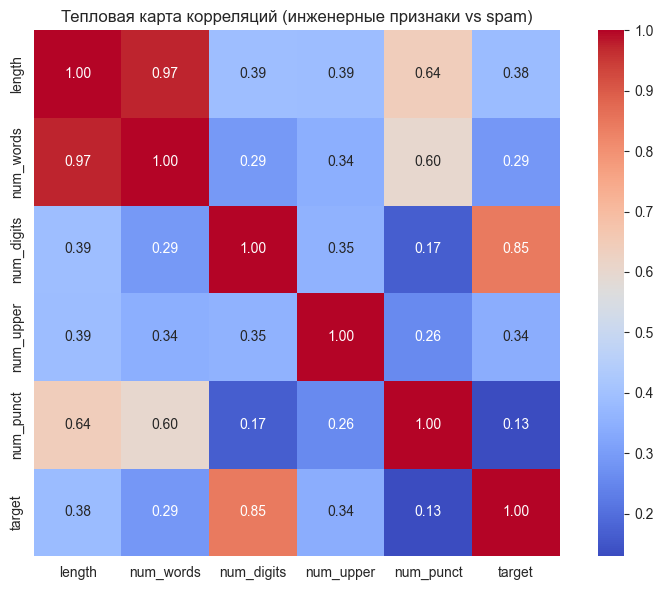

In [4]:
feat_cols = ["length", "num_words", "num_digits", "num_upper", "num_punct", "target"]
plt.figure(figsize=(8, 6))
sns.heatmap(data[feat_cols].corr(), annot=True, cmap="coolwarm", fmt=".2f", square=True)
plt.title("Тепловая карта корреляций (инженерные признаки vs spam)")
plt.tight_layout()
plt.show()

## 5. Обучение модели

In [5]:
model = MultinomialNB()
model.fit(X_train, y_train)

print("Классы модели:", model.classes_)
print("Размер словаря:", len(vectorizer.vocabulary_))
print("Априорные вероятности классов:", np.exp(model.class_log_prior_))

Классы модели: [0 1]
Размер словаря: 3366
Априорные вероятности классов: [0.86588921 0.13411079]


## 6. Прогнозы модели

In [6]:
y_pred  = model.predict(X_test)
y_proba = model.predict_proba(X_test)[:, 1]

print("Первые 15 прогнозов:", y_pred[:15])
print("Реальные значения:  ", y_test.values[:15])

acc  = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred)
rec  = recall_score(y_test, y_pred)
f1   = f1_score(y_test, y_pred)
auc  = roc_auc_score(y_test, y_proba)

print(f"\nAccuracy:  {acc:.4f}")
print(f"Precision: {prec:.4f}")
print(f"Recall:    {rec:.4f}")
print(f"F1-score:  {f1:.4f}")
print(f"ROC-AUC:   {auc:.4f}")

print("\nClassification report:")
print(classification_report(y_test, y_pred, target_names=["ham", "spam"]))

Первые 15 прогнозов: [0 0 0 1 0 0 1 0 0 0 0 0 0 0 0]
Реальные значения:   [0 0 0 1 0 0 1 0 0 0 0 0 0 0 0]

Accuracy:  0.9865
Precision: 0.9589
Recall:    0.9396
F1-score:  0.9492
ROC-AUC:   0.9899

Classification report:
              precision    recall  f1-score   support

         ham       0.99      0.99      0.99       966
        spam       0.96      0.94      0.95       149

    accuracy                           0.99      1115
   macro avg       0.97      0.97      0.97      1115
weighted avg       0.99      0.99      0.99      1115



## 7. Графики выходных результатов

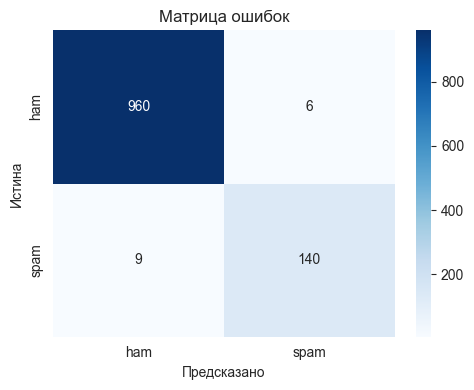

In [7]:
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["ham", "spam"], yticklabels=["ham", "spam"])
plt.xlabel("Предсказано")
plt.ylabel("Истина")
plt.title("Матрица ошибок")
plt.tight_layout()
plt.show()

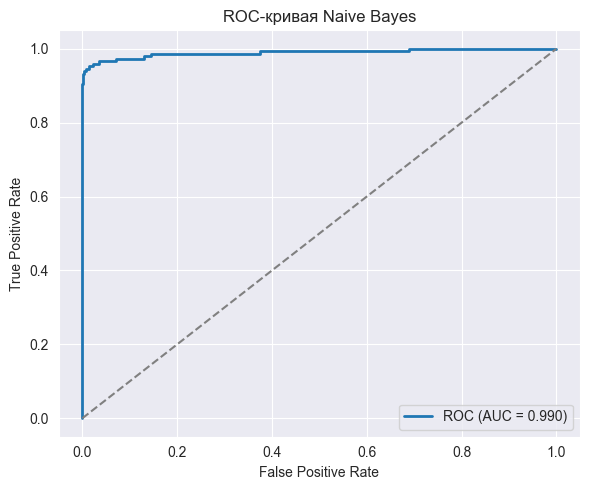

In [8]:
fpr, tpr, _ = roc_curve(y_test, y_proba)
plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, linewidth=2, label=f"ROC (AUC = {auc:.3f})")
plt.plot([0, 1], [0, 1], "--", color="gray")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC-кривая Naive Bayes")
plt.legend()
plt.tight_layout()
plt.show()

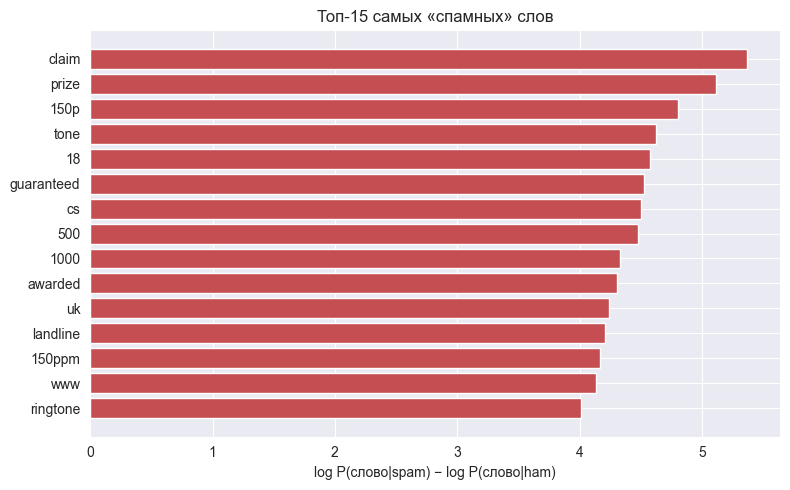

In [9]:
feature_names = np.array(vectorizer.get_feature_names_out())
log_prob = model.feature_log_prob_  # (n_classes, n_features)
top_n = 15

spam_minus_ham = log_prob[1] - log_prob[0]
top_idx = np.argsort(spam_minus_ham)[-top_n:]

plt.figure(figsize=(8, 5))
plt.barh(feature_names[top_idx], spam_minus_ham[top_idx], color="#C44E52")
plt.xlabel("log P(слово|spam) − log P(слово|ham)")
plt.title(f"Топ-{top_n} самых «спамных» слов")
plt.tight_layout()
plt.show()